# Cardiovascular Disease Predictive Modelling

### Project Overview

This project analyzes the Framingham Heart Study dataset from Kaggle to build a logistic regression model that predicts a patient's 10-year risk of developing coronary heart disease (CHD). 

The goal is twofold: to explore key health drivers in the clinical data and to create an early warning system that flags high-risk patients before CHD develops.

### Model Performance and Key Results

In a medical screening tool, missing a sick patient (a false negative) can be life-threatening, while mistakenly flagging a healthy patient for extra testing (a false positive) carries little practical harm. For this reason, the model prioritizes Recall — the ability to catch as many true cardiovascular cases as possible.

Using Youden’s J-Statistic, the optimal decision threshold was set to 0.44. At this threshold, the model achieved an 80% Recall rate, successfully identifying 4 out of every 5 patients at risk of heart disease. Overall prediction accuracy reached 59%, reflecting a deliberate trade-off that accepts extra false alarms to ensure high-risk individuals are not overlooked.

### Limitations of the Model

- Age and Gender Bias: The model has severe performance disparities across demographic groups. It tends to over-predict risk in men over 50 (generating high false alarms) while under-predicting risk in women over 50 (missing true cases).

- Geographic Constraint: Because all patient data originates from a single town in Massachusetts, the findings may not apply directly to broader, more diverse populations.

### Clinical Application

- Due to these limitations, the model should not be used as a standalone diagnostic tool.
- In clinical practice, it is best suited as a preliminary triage aid—used with a lowered screening threshold for women over 50 to avoid missed cases, and paired with secondary testing for men over 50 to filter out false alarms.

### Data Description

**Demographic**:
- sex: male or female
- age: in years
- education: from 1 to 4.

**Behavioral**:
- is_smoking: yes or no
- cigs_per_day: average number of cigarettes smoked in a day

**Medical history**:
- bp_meds (blood pressure medication): 1 or 0 (yes or no)
- prevalent_stroke: 1 or 0 (yes or no)
- prevalent_hyp (hypertensive): 1 or 0 (yes or no)
- diabetes: 1 or 0 (yes or no)

**Current medical data**:
- tot_chol (total cholesterol)
- sys_bp (systolic blood pressure)
- dia_bp (diastolic blood pressure)
- bmi (body mass index)
- heart_rate
- glucose (glucose level)

**Dependent variable**:
- ten_year_chd (10 year risk of coronary heart disease): 1 or 0 (yes or no)

### Agenda

1. Data loading and cleaning
2. EDA
3. Modelling
4. Conclusions and recommendations

# 1. Data Loading and Cleaning

### 1.1. Data Loading

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [11]:
plt.rcParams.update({
    "axes.labelsize": 12,
    "axes.titlesize": 16,
    "axes.titleweight": "bold"
})

Setting up global parameters for charts below

In [12]:
df = pd.read_csv("train.csv")
df.sample(10)

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
295,295,48,2.0,M,NO,0.0,0.0,0,0,0,215.0,127.0,81.0,24.87,76.0,76.0,0
3010,3010,54,1.0,F,NO,0.0,0.0,0,1,0,306.0,195.0,110.0,32.10,72.0,68.0,0
752,752,49,4.0,M,YES,40.0,0.0,0,0,0,222.0,118.5,82.0,28.47,88.0,87.0,0
489,489,42,2.0,F,NO,0.0,0.0,0,0,0,176.0,136.0,87.0,30.91,80.0,73.0,0
950,950,61,2.0,F,YES,20.0,0.0,0,1,0,231.0,128.0,87.0,26.30,82.0,93.0,0
1377,1377,54,1.0,F,NO,0.0,0.0,0,0,0,248.0,131.5,83.0,26.84,67.0,63.0,0
2107,2107,38,1.0,M,YES,9.0,0.0,0,0,0,274.0,120.0,80.0,25.17,80.0,68.0,0
777,777,57,3.0,F,YES,20.0,0.0,0,0,0,267.0,102.0,62.0,20.34,60.0,NaN,0
2116,2116,50,4.0,M,YES,20.0,0.0,0,1,0,261.0,180.0,100.0,25.90,92.0,66.0,1
618,618,36,3.0,M,NO,0.0,0.0,0,0,0,180.0,111.0,73.0,27.78,71.0,80.0,0


In [13]:
rows, columns = df.shape
print("Columns:", columns)
print("Rows:", rows)

Columns: 17
Rows: 3390


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   str    
 4   is_smoking       3390 non-null   str    
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64  
dtypes: float64(9), int64(6), 

In [15]:
df.describe().round(2)

,id,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3390.00,3390.00,3303.00,3368.00,3346.00,3390.00,3390.00,3390.00,3352.00,3390.00,3390.00,3376.00,3389.00,3086.00,3390.00
mean,1694.50,49.54,1.97,9.07,0.03,0.01,0.32,0.03,237.07,132.60,82.88,25.79,75.98,82.09,0.15
std,978.75,8.59,1.02,11.88,0.17,0.08,0.46,0.16,45.25,22.29,12.02,4.12,11.97,24.24,0.36
min,0.00,32.00,1.00,0.00,0.00,0.00,0.00,0.00,107.00,83.50,48.00,15.96,45.00,40.00,0.00
25%,847.25,42.00,1.00,0.00,0.00,0.00,0.00,0.00,206.00,117.00,74.50,23.02,68.00,71.00,0.00
50%,1694.50,49.00,2.00,0.00,0.00,0.00,0.00,0.00,234.00,128.50,82.00,25.38,75.00,78.00,0.00
75%,2541.75,56.00,3.00,20.00,0.00,0.00,1.00,0.00,264.00,144.00,90.00,28.04,83.00,87.00,0.00
max,3389.00,70.00,4.00,70.00,1.00,1.00,1.00,1.00,696.00,295.00,142.50,56.80,143.00,394.00,1.00


### 1.2. Data Standartization

I'll need to:
- Rename the columns to snake_case.
- Remove redundant index column.
- Remove irrelevant education column, as it can't be used to predict heart disease.
- Check for duplicate data.
- Transform values from is_smoking and sex columns into binary values.

In [16]:
df = df.drop(columns=["id", "education"])

In [17]:
df = df.rename(columns={
    "cigsPerDay": "cigs_per_day",
    "BPMeds": "bp_meds",
    "prevalentStroke": "prevalent_stroke",
    "prevalentHyp": "prevalent_hyp",
    "totChol": "tot_chol",
    "sysBP": "sys_bp",
    "diaBP": "dia_bp",
    "BMI": "bmi",
    "heartRate": "heart_rate",
    "TenYearCHD": "ten_year_chd"
})

In [18]:
df.duplicated().any()

np.False_

In [19]:
sex_map = {"M": 1, "F": 0}
smoker_map = {"YES": 1, "NO": 0}

df["sex_binary"] = df["sex"].map(sex_map)
df["smoking_binary"] = df["is_smoking"].map(smoker_map)

In [20]:
df.sample(10)

,age,sex,is_smoking,cigs_per_day,bp_meds,prevalent_stroke,prevalent_hyp,diabetes,tot_chol,sys_bp,dia_bp,bmi,heart_rate,glucose,ten_year_chd,sex_binary,smoking_binary
23,63,F,NO,0.0,0.0,0,1,0,226.0,172.5,98.0,26.47,87.0,81.0,0,0,0
116,39,F,NO,0.0,0.0,0,0,0,213.0,125.0,87.0,16.73,110.0,75.0,0,0,0
512,51,M,YES,9.0,0.0,0,1,0,696.0,157.0,87.0,24.44,95.0,84.0,0,1,1
2826,49,F,YES,9.0,0.0,0,1,0,231.0,137.0,96.5,29.30,70.0,NaN,0,0,1
1714,43,F,YES,20.0,0.0,0,0,0,208.0,119.0,69.0,19.48,67.0,73.0,0,0,1
1584,49,M,YES,20.0,0.0,0,1,0,193.0,172.0,105.0,19.70,90.0,77.0,1,1,1
2883,61,F,NO,0.0,0.0,0,1,0,210.0,179.0,100.0,21.64,78.0,95.0,0,0,0
1260,55,F,NO,0.0,0.0,0,1,0,180.0,165.0,88.0,22.57,68.0,77.0,1,0,0
2678,38,F,YES,5.0,0.0,0,0,0,192.0,130.0,80.0,27.51,75.0,90.0,0,0,1
1365,37,M,YES,15.0,0.0,0,0,0,231.0,135.0,79.0,28.46,73.0,67.0,0,1,1


### 1.3. Missing data

I'll need to:
- Count missing data
- Address the way to deal with missing data in the modelling stage.

In [21]:
missing_sum = df.isna().sum().reset_index()
missing_sum.columns = ["column_name", "missing_data_count"]
missing_pct = ((df.isna().mean())*100).round(2).reset_index()
missing_pct.columns = ["column_name", "missing_data_pct"]
missing_df = pd.merge(
    missing_sum,
    missing_pct,
    on="column_name"
)
missing_df

,column_name,missing_data_count,missing_data_pct
0,age,0,0.00
1,sex,0,0.00
2,is_smoking,0,0.00
3,cigs_per_day,22,0.65
4,bp_meds,44,1.30
5,prevalent_stroke,0,0.00
6,prevalent_hyp,0,0.00
7,diabetes,0,0.00
8,tot_chol,38,1.12
9,sys_bp,0,0.00


- 6/15 columns have missing values.
- Dependent variable column does not have missing values.
- I need to find out if data is missing completely at random.

<Axes: >

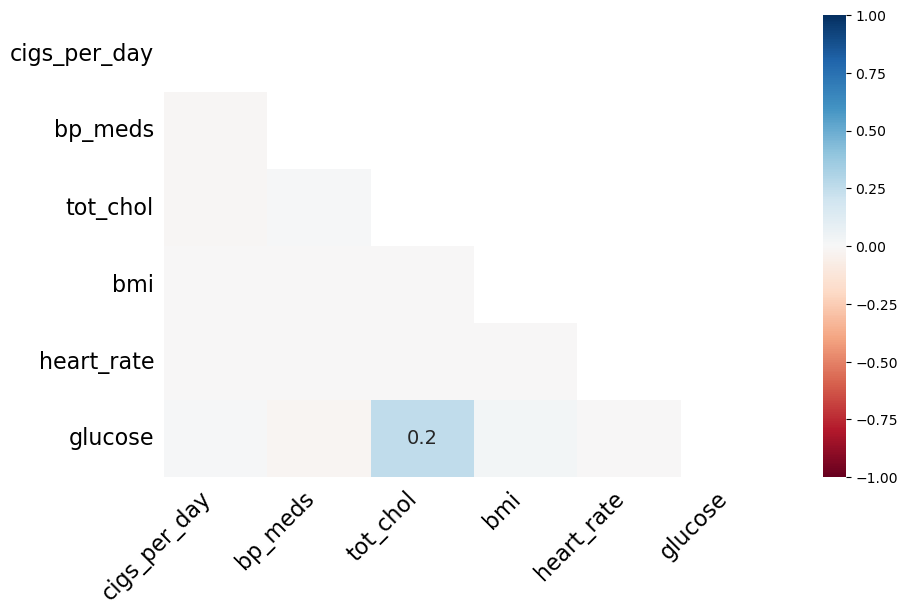

In [22]:
fig, ax1 = plt.subplots(figsize=(10, 6))
msno.heatmap(df, ax=ax1)

It seems that values are missing completely at random, as correlation is either non-existant or very weak (as with tot_chol and glucose columns).

Missing values will be imputed at the modelling stage.

### 1.4. Checking for outliers

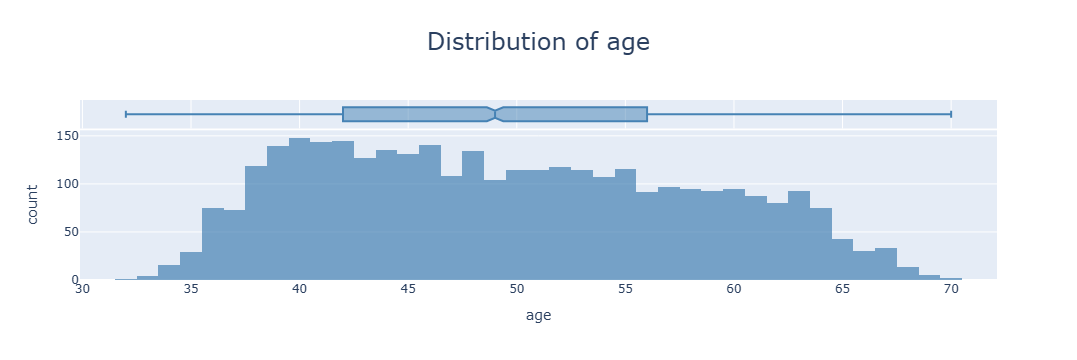

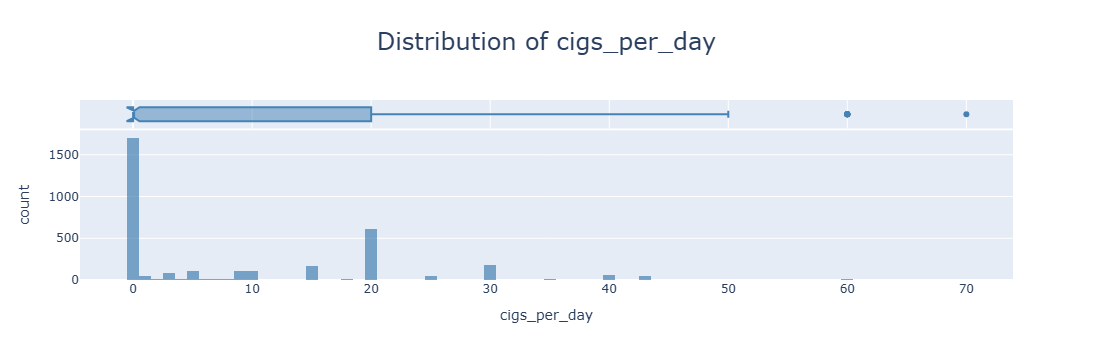

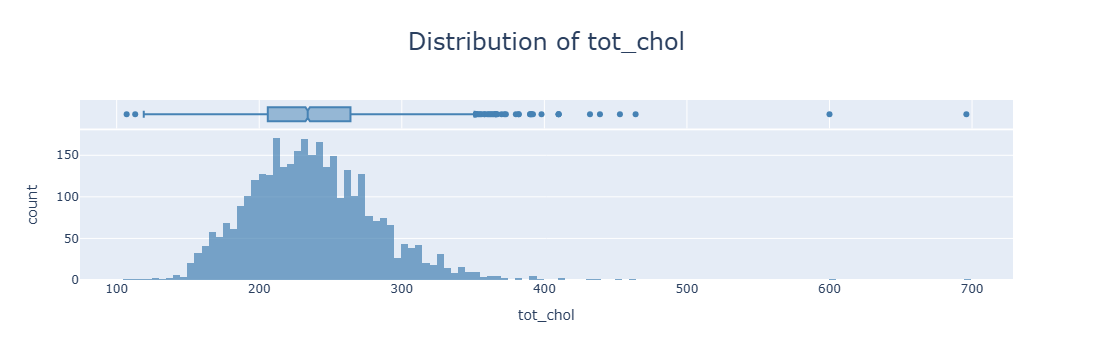

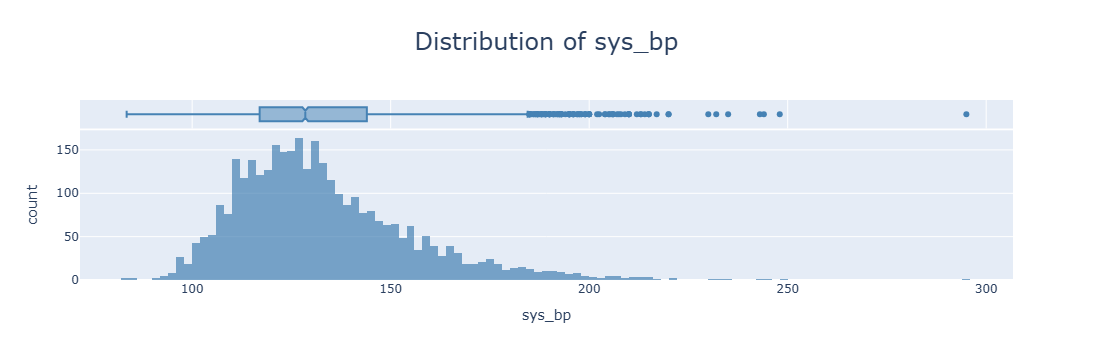

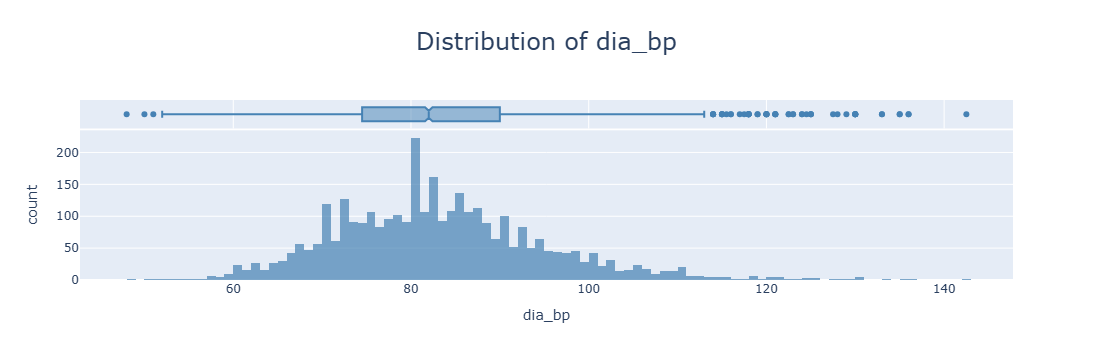

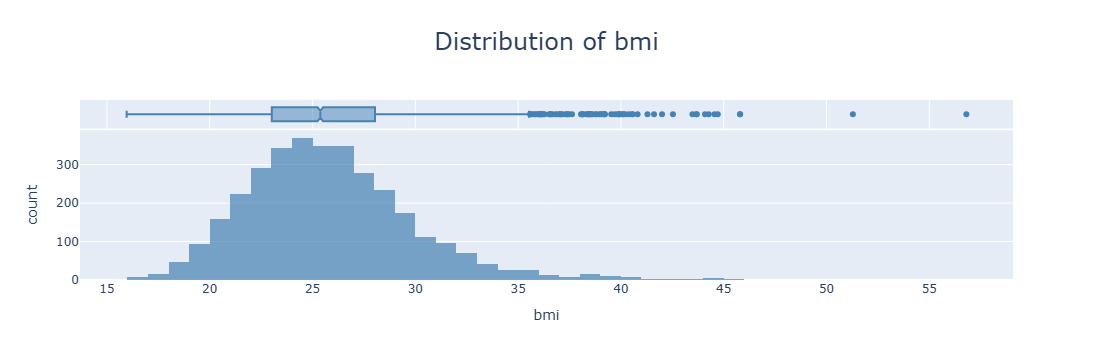

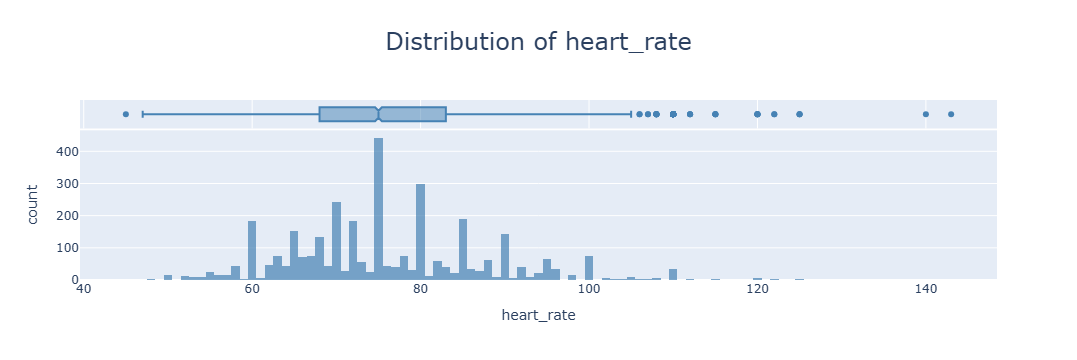

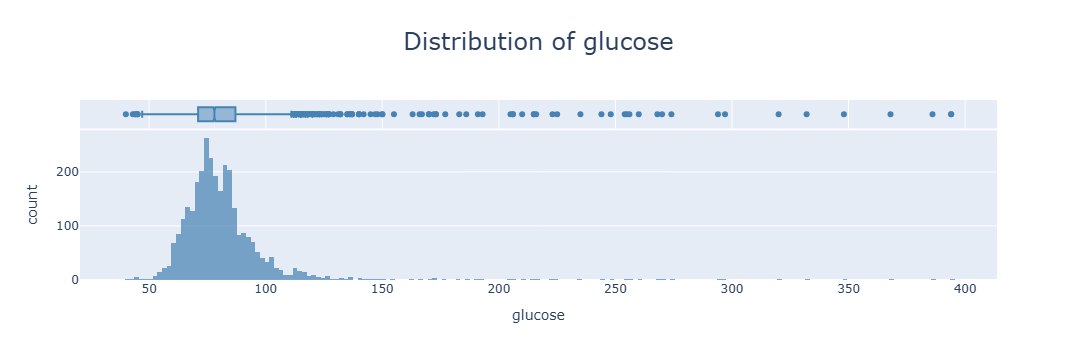

In [23]:
numeric_cols = ["age", "cigs_per_day",
                "tot_chol", "sys_bp", "dia_bp",
                "bmi", "heart_rate", "glucose"]

for col in numeric_cols:
    fig = px.histogram(
        df,
        x=col,
        marginal="box",
        title=f"Distribution of {col}",
        color_discrete_sequence=["steelblue"],
        opacity=0.7
    )

    fig.update_layout(
        title={
            'font': {'size': 24},
            'x': 0.5,
            'xanchor': 'center'
        }
    )

    fig.show()


- "age" column has no outliers
- All the other columns are skewed to the right

Glucose column is very strongly skewed to the right. I'm going to log transform this column and try to normalize the distribution.

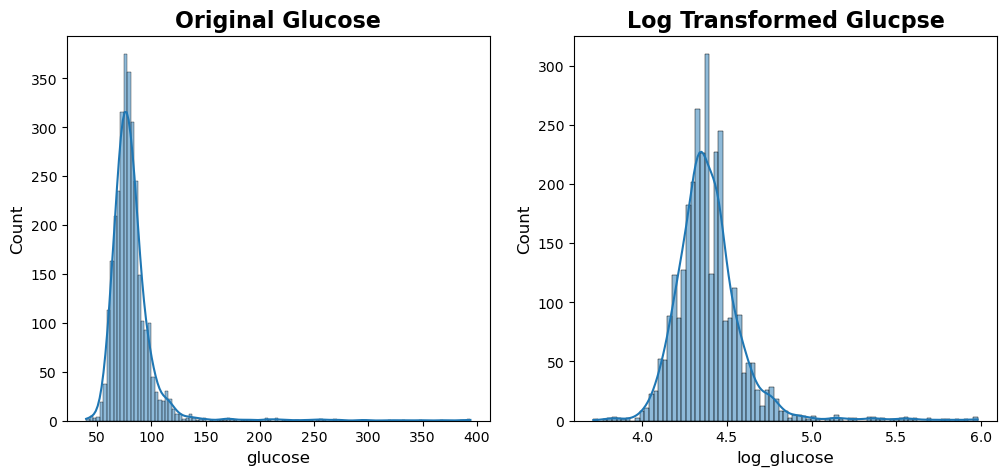

In [24]:
df["log_glucose"] = np.log1p(df["glucose"])
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["glucose"], kde=True, ax=ax[0]).set_title("Original Glucose")
sns.histplot(df["log_glucose"], kde=True, ax=ax[1]).set_title("Log Transformed Glucpse")
plt.show()

In [25]:
df.drop(columns=["glucose"], inplace=True)

We are going to clip the outliers at 1st and 99th percentile values so that some of the extreme results would still register as being very high or very low, without skewing the data that much.

In [26]:
def windsorization (df, columns, limits=(0.01, 0.99)):
    for col in columns:
        lower_val = df[col].quantile(limits[0])
        upper_val = df[col].quantile(limits[1])
        df[col] = df[col].clip(lower=lower_val, upper=upper_val)
    return df

features = [
    "tot_chol", "sys_bp", "dia_bp",
    "bmi", "heart_rate", "log_glucose"
]
df = windsorization(df, features)

#2. Exploratory Data Analysis

My goal for this part:
- Find the strongest predictors for ten_year_chd.
- Find which columns are redundant and could be explained by others.
- Engineer some better features if necessary.

### 2.1. Correlation analysis

<Axes: >

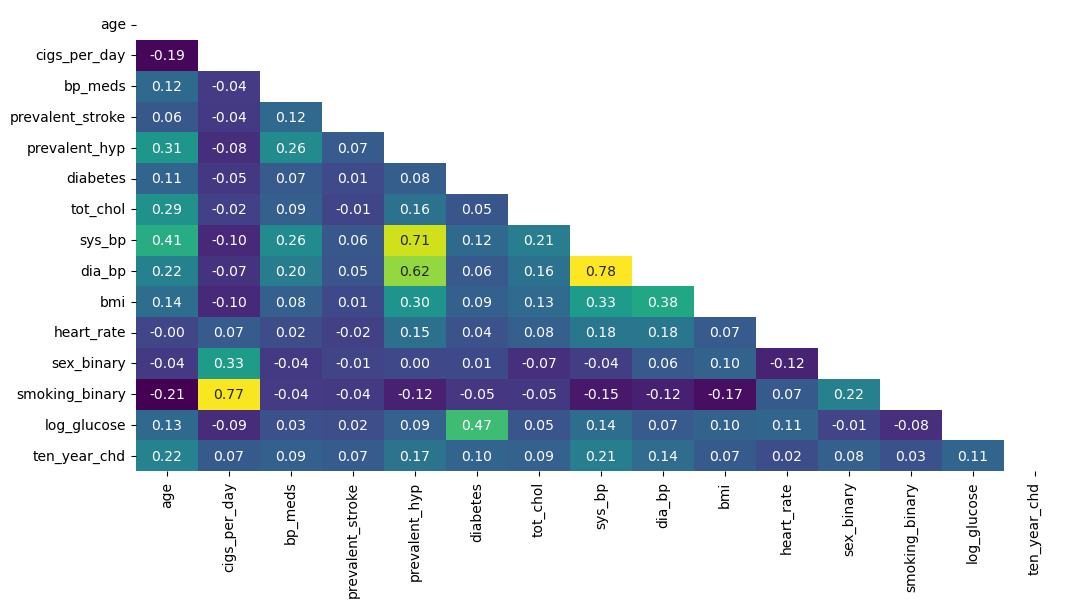

In [27]:

"""
After adding new columns, I'm sorting the dataframe to
make correlation matrix easier to read.
"""
y = "ten_year_chd"
df = df[[c for c in df.columns if c != y] + [y]]

corr_matrix = df.corr(numeric_only=True)
corr_matrix_lower = corr_matrix.where(
    np.tril(np.ones(corr_matrix.shape), k=-1)
    .astype(bool)
)
corr_matrix_lower.index = corr_matrix.columns
corr_matrix_lower.columns = corr_matrix.columns

fig, axes = plt.subplots(figsize=(12, 6))
sns.heatmap(
    corr_matrix_lower,
    annot=True,
    cmap="viridis",
    fmt=".2f",
    cbar=False
)

Strongest variables:
- age
- sys_bp

Variables I'm removing:
- dia_bp and prevalent_hyp: both strongly correlated with sys_bp, which is a stronger predictor.

### 2.2. Distribution of continuous variables

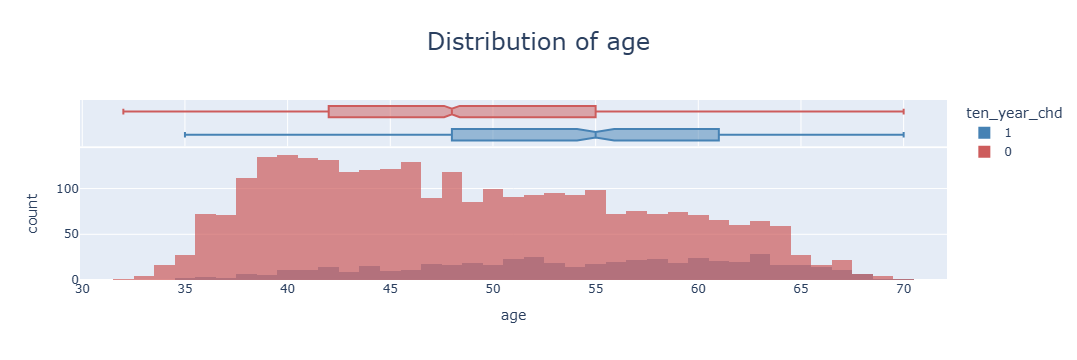

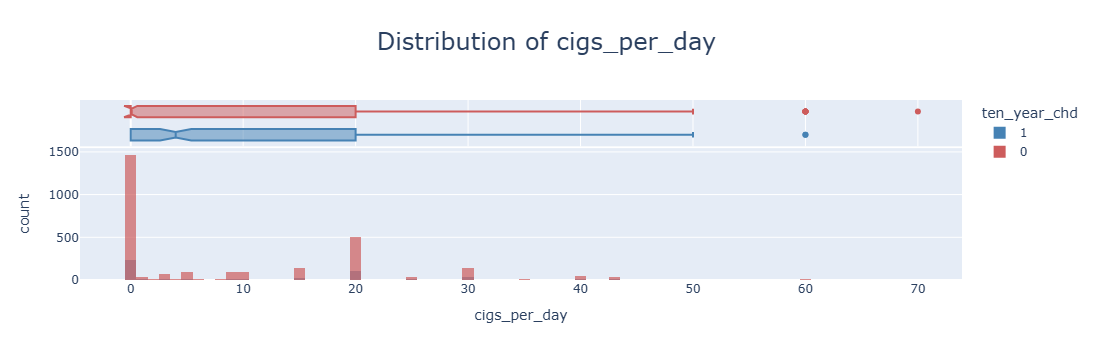

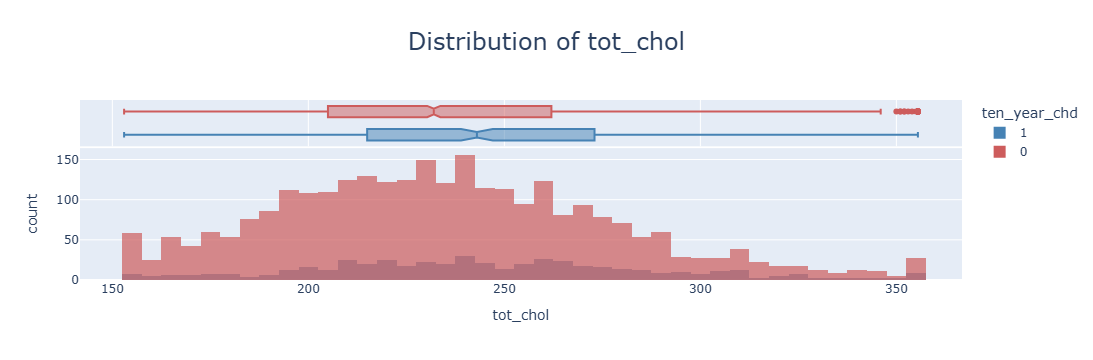

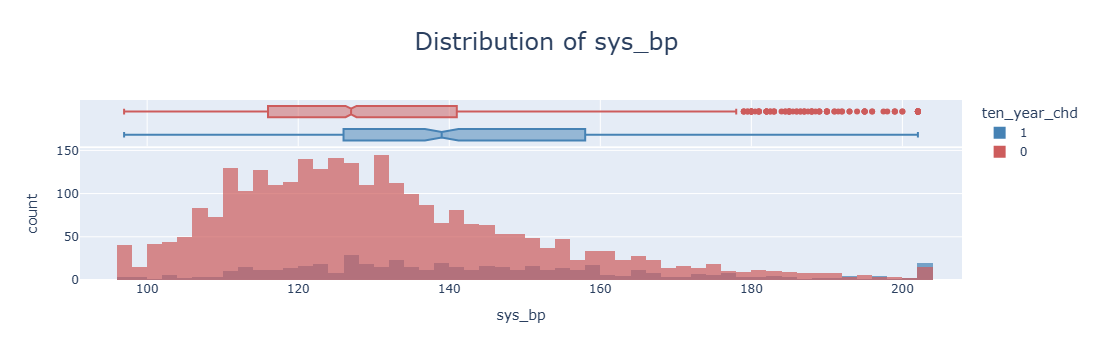

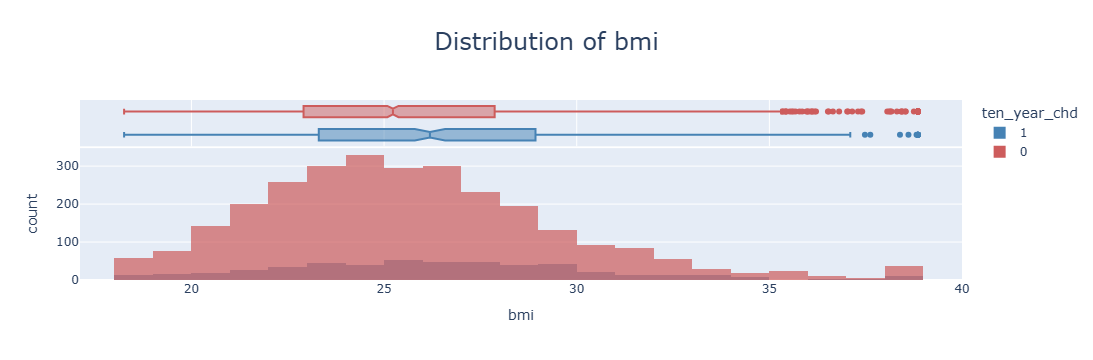

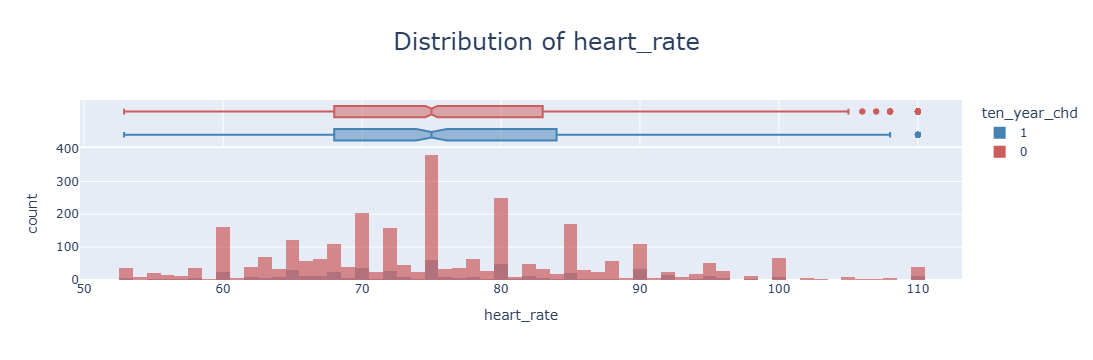

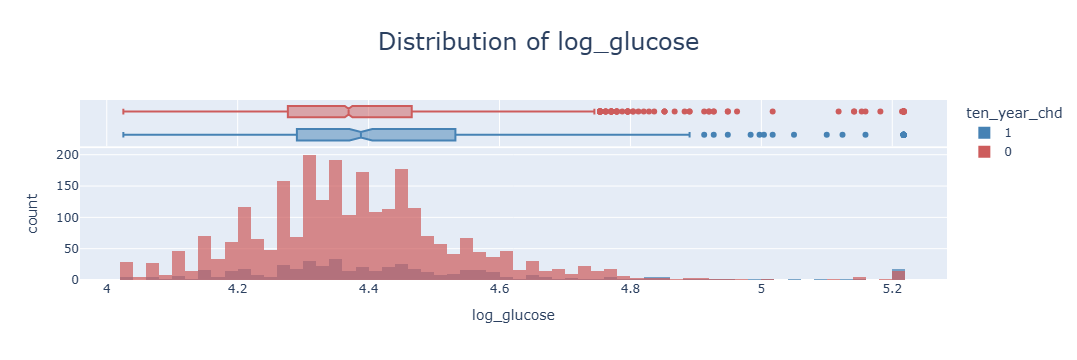

In [28]:
numeric_cols = ["age", "cigs_per_day",
                "tot_chol", "sys_bp", "bmi",
                "heart_rate", "log_glucose"]
color_map = {0: "indianred", 1: "steelblue"}

for col in numeric_cols:
    fig = px.histogram(
        df,
        x=col,
        color="ten_year_chd",
        color_discrete_map=color_map,
        marginal="box",
        title=f"Distribution of {col}",
        barmode="overlay",
        opacity=0.7
    )

    fig.update_layout(
        title={
            "font": {"size": 24},
            "x": 0.5,
            "xanchor": "center"
        }
    )
    fig.show()

Variables I'm removing:
- heart_rate - no difference in distribution.
- cigs_per_day have very unsual distribution which could affect the results. Plus, it is less reliably measured value than simple smoking_binary.

### 2.3. Distribution of binary variables

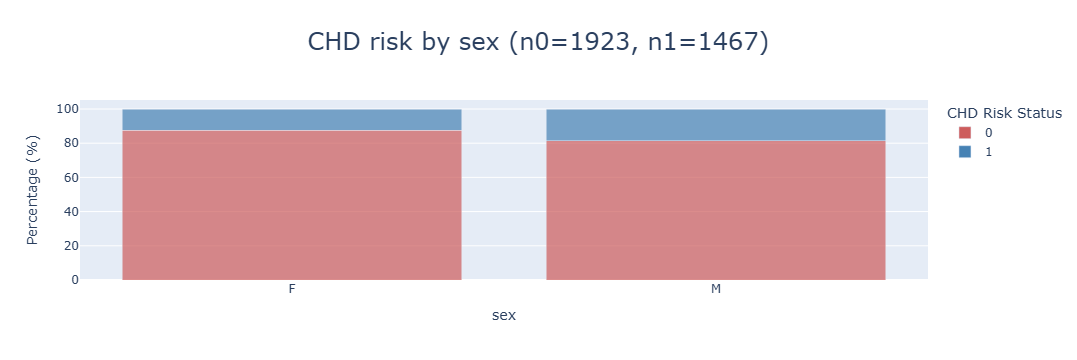

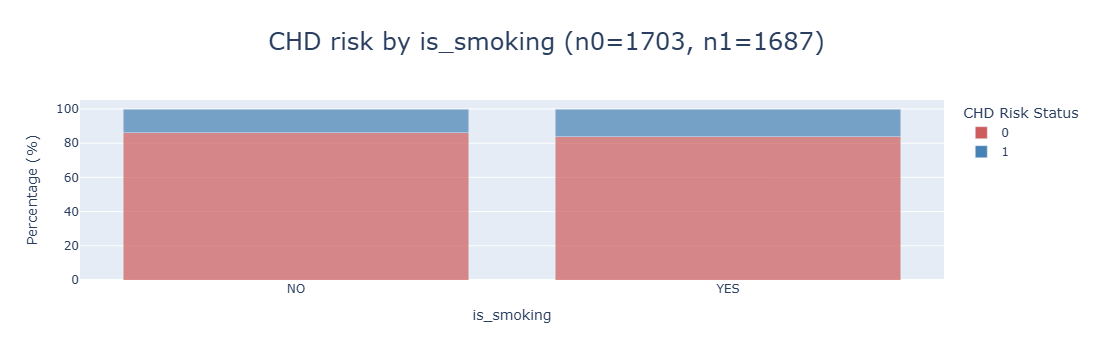

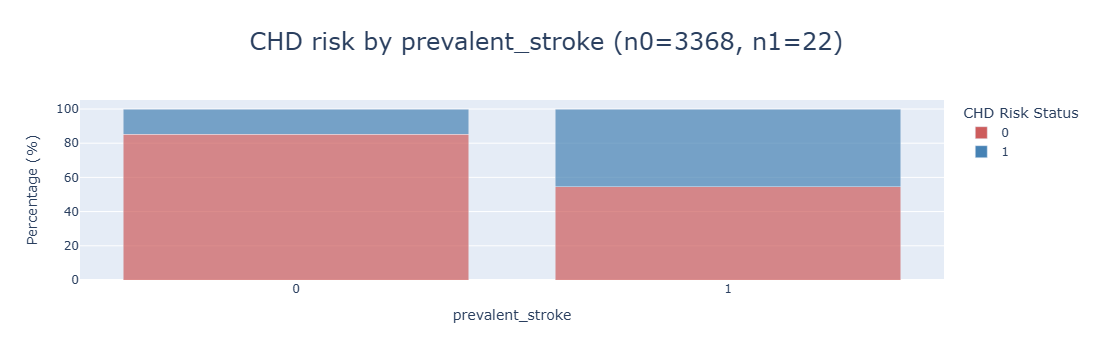

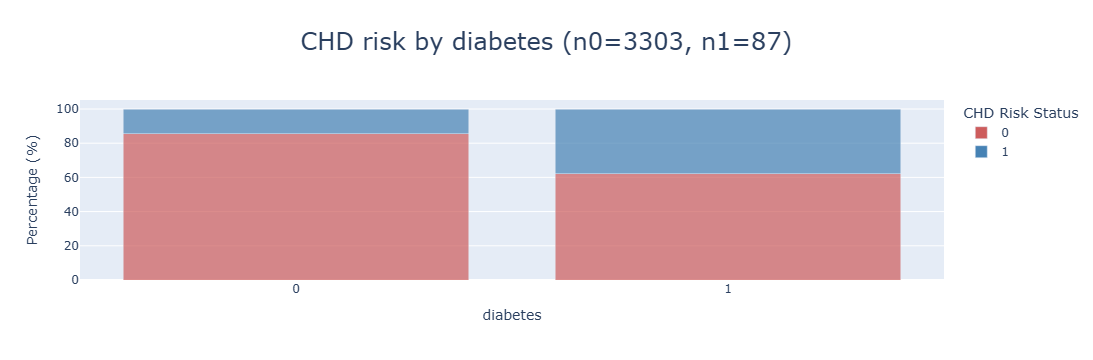

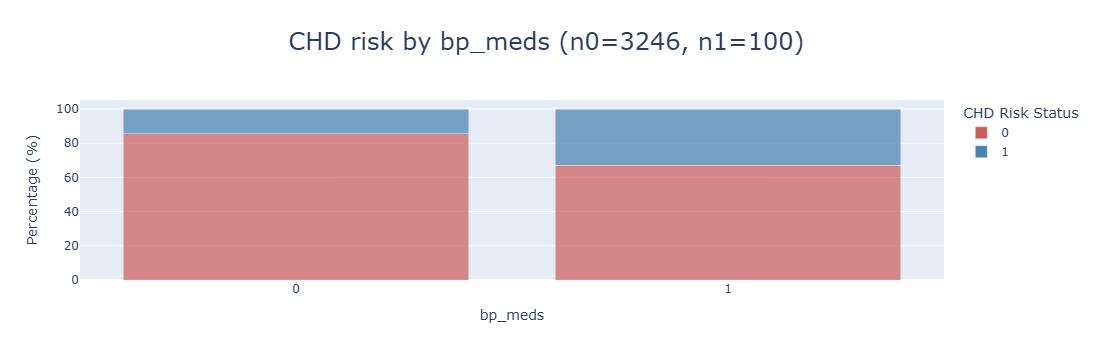

In [29]:
binary_cols = ["sex", "is_smoking", "prevalent_stroke",
               "diabetes", "bp_meds"]
color_map = {0: "indianred", 1: "steelblue"}

for col in binary_cols:
    n_counts = df[col].value_counts()
    n0 = n_counts.iloc[0]
    n1 = n_counts.iloc[1]
    ct = pd.crosstab(
        df[col],
        df["ten_year_chd"],
        normalize="index"
    ).round(3)*100
    ct = ct.reset_index().melt(
        id_vars=col,
        value_name="chd_pct"
    )

    fig = px.bar(
        ct,
        x=col,
        y="chd_pct",
        color="ten_year_chd",
        color_discrete_map=color_map,
        title=f"CHD risk by {col} (n0={n0}, n1={n1})",
        labels={
            "chd_pct": "Percentage (%)",
            "ten_year_chd": "CHD Risk Status"
        },
        barmode="stack",
        opacity=0.7
    )

    fig.update_layout(
        title={
            "font": {"size": 24},
            "x": 0.5,
            "xanchor": "center"
        }
    )

    fig.show()

Variables I'm reworking:
- I've chosen to combine prevalent_stroke, diabetes and bp_meds variable into one single "comorbidities" variable that becomes positive when the person has least 1 of 3 possible health issues.

### 2.4. Feature engineering

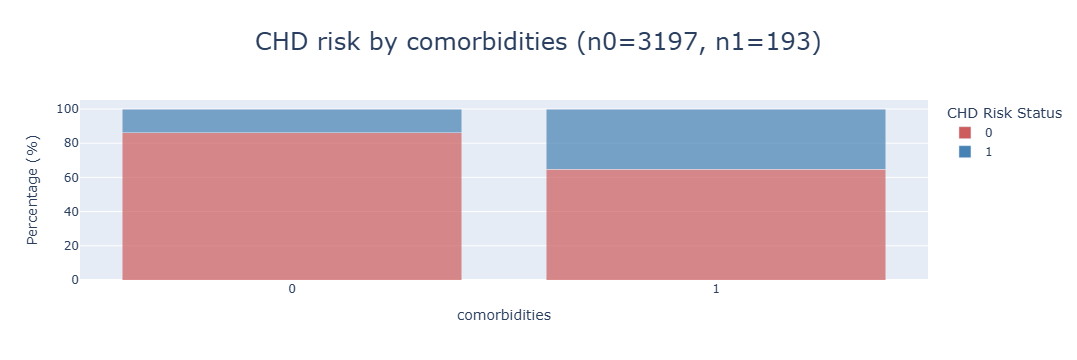

In [30]:
df["comorbidities"] = (
    (df['prevalent_stroke'] == 1) |
     (df['bp_meds'] == 1) |
    (df["diabetes"])
     ).astype(int)

n_counts = df["comorbidities"].value_counts()
n0 = n_counts.iloc[0]
n1 = n_counts.iloc[1]
ct = pd.crosstab(
    df["comorbidities"],
    df["ten_year_chd"],
    normalize="index"
).round(3)*100
ct = ct.reset_index().melt(
    id_vars="comorbidities",
    value_name="chd_pct"
)

color_map = {0: "indianred", 1: "steelblue"}
fig = px.bar(
    ct,
    x="comorbidities",
    y="chd_pct",
    color="ten_year_chd",
    color_discrete_map=color_map,
    title=f"CHD risk by {"comorbidities"} (n0={n0}, n1={n1})",
    labels={
        "chd_pct": "Percentage (%)",
        "ten_year_chd": "CHD Risk Status"
    },
    barmode="stack",
    opacity=0.7
)

fig.update_layout(
    title={
        "font": {"size": 24},
        "x": 0.5,
        "xanchor": "center"
    }
)

fig.show()

### 2.5. One Final Look at the Correlation Matrix

Predictors I've selected:
- age
- sex
- comorbidities
- sys_bp
- tot_chol
- smoking_binary
- bmi
- log_glucose

<Axes: >

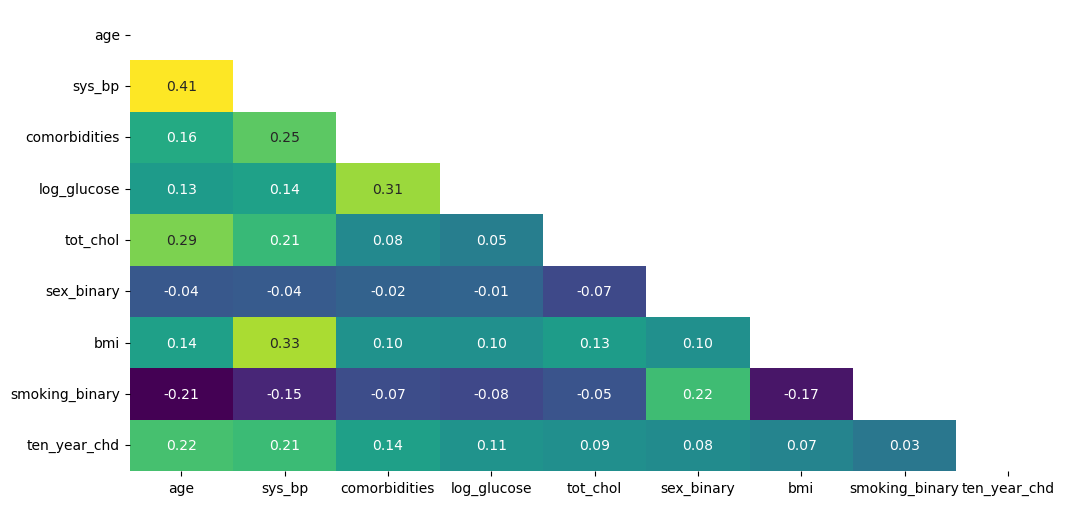

In [31]:
features = [
    "age", "sys_bp", "comorbidities",
    "log_glucose", "tot_chol", "sex_binary",
    "bmi", "smoking_binary", "ten_year_chd"
]
corr_matrix = df[features].corr()
corr_matrix_lower = corr_matrix.where(
    np.tril(np.ones(corr_matrix.shape), k=-1)
    .astype(bool)
)
corr_matrix_lower.index = corr_matrix.columns
corr_matrix_lower.columns = corr_matrix.columns

fig, axes = plt.subplots(figsize=(12, 6))
sns.heatmap(
    corr_matrix_lower,
    annot=True,
    cmap="viridis",
    fmt=".2f",
    cbar=False
)

# 3. Modelling


### 3.1. Dividing data into training and testing sets

- I'm choosing to put 20% of my data in the testing set.

In [32]:
features = [
    "log_glucose", "bmi", "tot_chol",
    "sys_bp", "age", "comorbidities",
    "sex_binary", "smoking_binary"
]
y = df["ten_year_chd"]
x = df[features]
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=777
)

### 3.2. Missing data imputation

- I'm using simple imputer to inpute median values.
- The model was fit training set, while missing values from testing set was just transformed.

In [33]:
features_to_impute = (
    x_train.select_dtypes(include=["number"])
    .columns
)
imputer = SimpleImputer(strategy="median")
x_train[features_to_impute] = imputer.fit_transform(
    x_train[features_to_impute]
)
x_test[features_to_impute] = imputer.transform(
    x_test[features_to_impute]
)


### 3.3. Fitting the model

- I've used pipeline method to scaler the model and then fit it, in that order.
- Standard scaler was used (scaling, based on standard deviation).
- Logistic regression was used, per task requirement.
- I've calculated maximum likelihood score (y_proba).

In [34]:
model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
         class_weight="balanced",
         random_state=777
         ))
])

model_pipeline.fit(x_train, y_train)
y_proba = model_pipeline.predict_proba(x_test)[:, 1]

### 3.4. Cross validation
- For training set I'm using k-fold cross validation with k=5.
- For testing set - I want to see low (<0.05) standard deviation to make sure the data is not volatile.
- For test set - I want the AUC score to be around the average of training set. If it's not the case, I'd be overfitting.

In [35]:
train_auc = cross_val_score(
    model_pipeline,
    x_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)


print(f"All Training Set AUC Scores: {train_auc}")
print(f"Average AUC: {train_auc.mean():.2f}")
print(f"Standard Deviation: {train_auc.std():.2f}")

All Training Set AUC Scores: [0.74014602 0.71816306 0.72970729 0.73936903 0.71442206]
Average AUC: 0.73
Standard Deviation: 0.01


In [36]:
test_auc = roc_auc_score(y_test, y_proba)

print(f"Test Set AUC Score: {test_auc:.2f}")

Test Set AUC Score: 0.71


### 3.5. Choosing Threshold for Target Metric
- I'm calculating Youden's J-Statistic to choose the optimal threshold.

In [37]:
"""
fpr - false positive rate; tpr - true positive rate.
np.argmax - finds the index where J-statistic is the highest.
"""
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (Youden's J): {optimal_threshold:.4f}")

Optimal Threshold (Youden's J): 0.4585


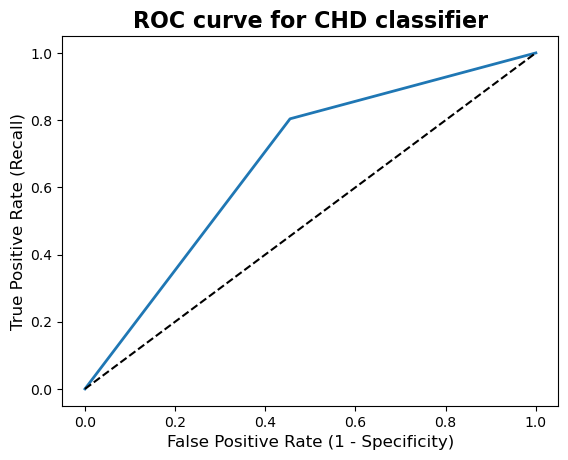

In [38]:
y_pred = (y_proba >= 0.44).astype(int)

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1], [0,1], "k--" )
plt.title("ROC curve for CHD classifier")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.show()

### 3.6. Confusion Matrix

- Accuracy - 59%
- Weighed avg f1-score - 64%
- Precision - 24%
- Recall - 80%

Recall metric is the most important one for this task because high number of false negatives could potentially be life-threatening, while high number of false positives wouldn't have negative consequences in practice.

We're able to maintain 80% recall without having an obnoxious number of false positives.

              precision    recall  f1-score   support

           0       0.94      0.55      0.69       576
           1       0.24      0.80      0.37       102

    accuracy                           0.58       678
   macro avg       0.59      0.67      0.53       678
weighted avg       0.83      0.58      0.64       678



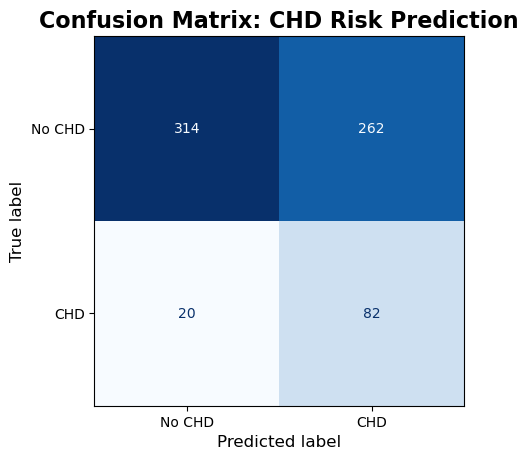

In [39]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No CHD", "CHD"]
)
display.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix: CHD Risk Prediction")
plt.show()

### 3.7. Further Examination of the Model
Why did the inacurracies emerge. I'm interested in:
- Model's formula.
- Figuring out the bias of this model. Because the model performed well in the testing data, we know that variance is low, therefore, bias must be high.

In [40]:
features = x_train.columns
coefs = model_pipeline.named_steps["logreg"].coef_[0]
df_coef = pd.DataFrame({
    "feature": features,
    "coeficient": coefs,
    "odds_ratio": np.exp(coefs)
}).sort_values(by="coeficient", ascending=False)

df_coef.round(3)

,feature,coeficient,odds_ratio
4,age,0.574,1.775
3,sys_bp,0.288,1.334
6,sex_binary,0.287,1.333
7,smoking_binary,0.244,1.276
5,comorbidities,0.160,1.174
2,tot_chol,0.140,1.151
0,log_glucose,0.102,1.108
1,bmi,0.026,1.026


- Age variable is massively overrepresented in this model. Its correlation with the target variable was 0.22 while it's coeficient in the formula is 0.574.
- Sex variable is also overrepresented. Its correlation with the target variable was 0.08 while it's coeficient in the formula is 0.287.

In [41]:
"""
False negatives dataframe
"""

df_test = x_test
df_test["ten_year_chd"] = y_test
df_test["pred"] = y_pred

df_test.loc[
    (df_test.pred == 0) &
     (df_test.ten_year_chd == 1)
]

,log_glucose,bmi,tot_chol,sys_bp,age,comorbidities,sex_binary,smoking_binary,ten_year_chd,pred
2493,4.290459,26.5900,153.00,114.000,47.0,0.0,1.0,1.0,1,0
1641,4.094345,25.1800,232.00,115.000,46.0,0.0,0.0,1.0,1,0
3349,4.369448,27.4000,242.00,129.000,46.0,0.0,0.0,0.0,1,0
410,4.234107,27.0500,211.00,127.500,45.0,0.0,0.0,0.0,1,0
2684,4.189655,28.6800,244.00,118.500,38.0,0.0,1.0,0.0,1,0
1276,4.644391,24.0400,242.00,118.500,36.0,0.0,1.0,1.0,1,0
2204,4.290459,27.0200,279.00,135.000,52.0,0.0,0.0,0.0,1,0
3286,4.158883,22.8600,323.00,123.500,49.0,0.0,0.0,1.0,1,0
1062,4.234107,24.4000,210.00,103.000,40.0,0.0,0.0,1.0,1,0
1241,4.382027,20.8600,198.00,143.000,47.0,0.0,0.0,1.0,1,0


After examining false negatives dataframe we can clearly see model's bias regarding age:
- Median age value for all patients: **49**.
- Median age value for patients with confirmed chd risk: **55**.
- **Only 3 patients** were at or above the median age value for all patients.

Similarly, model is strongly biased towards diagnosing men.
- 17/20 of false negatives were women.

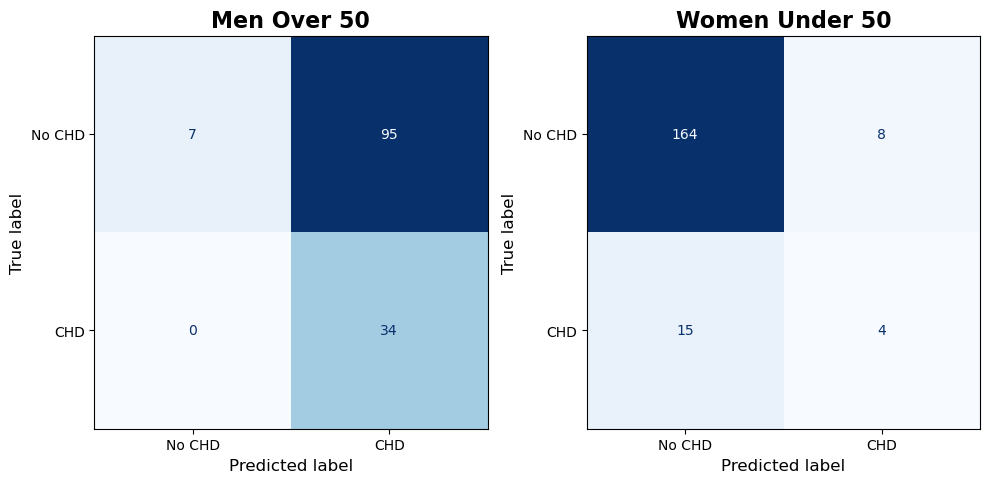

In [42]:
men_over_50 = (
    (df_test["sex_binary"] == 1) &
     (df_test["age"] > 50)
)
y_true_men = y_test[men_over_50]
y_pred_men = y_pred[men_over_50]

women_under_50 = (
    (df_test["sex_binary"] == 0) &
     (df_test["age"] < 50)
)
y_true_women = y_test[women_under_50]
y_pred_women = y_pred[women_under_50]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

cm_men = confusion_matrix(y_true_men, y_pred_men)
display_men = ConfusionMatrixDisplay(
    confusion_matrix=cm_men,
    display_labels=["No CHD", "CHD"]
)
display_men.plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Men Over 50")

cm_women = confusion_matrix(y_true_women, y_pred_women)
display_women = ConfusionMatrixDisplay(
    confusion_matrix=cm_women,
    display_labels=["No CHD", "CHD"]
)
display_women.plot(ax=ax[1], cmap="Blues", colorbar=False)
ax[1].set_title("Women Under 50")

plt.tight_layout()
plt.show()